# CSP + thermal energy storage

A standalone demonstration with thermal CSP charging, thermal TES state of charge, electric delivery, and integrated CSP+TES economics.

In [1]:
from pathlib import Path
import sys
import pandas as pd

root = Path.cwd()
while not (root / 'enliten').is_dir():
    if root.parent == root: raise RuntimeError('Run from inside the ENLITEN repository.')
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
from enliten import ChargingPath, Generation, LCOECalculator, Site, Storage, System
data_dir = root / 'examples' / 'data'

def profile(filename):
    frame = pd.read_csv(data_dir / filename)
    return pd.Series(frame['PNM'].to_numpy(float), index=pd.to_datetime(frame.iloc[:, 0], utc=True))

demand_full, csp_full = profile('PNM_demand.csv'), profile('PNM_csp_th_av.csv')
assert demand_full.index.equals(csp_full.index)
hours, start = 24 * 14, pd.Timestamp('2023-07-01', tz='UTC')
window = demand_full.index.get_loc(start)
load = (demand_full.iloc[window:window + hours] * 0.05).rename('load_MW')
tes_capacity_MWh_th, tes_power_MW_e = 2_500.0, 150.0
csp_tes_capex = tes_power_MW_e * 1_000 * 7_912

site = Site('microgrid')
csp = Generation('csp', site, csp_full.iloc[window:window + hours], 'thermal', False, False,
                 capex=csp_tes_capex, opex=tes_power_MW_e * 1_000 * 74.6)
tes = Storage('tes', site, tes_capacity_MWh_th, tes_power_MW_e, 'thermal', 'electric', 0.50,
              maximum_stored_energy_rate_MW=300.0, variable_opex_USD_per_MWh=3.8)
path = ChargingPath('csp', 'tes', 'thermal', 'thermal', 0.90, 300.0 / 0.90)
system = System(load, [tes, csp], [path])
system.timeseries.filter(regex='csp_to_tes|tes_MWh|tes_to_load').head(24)

,csp_to_tes_MWh_thermal,csp_to_tes_stored_MWh_thermal,tes_MWh_thermal,tes_to_load_MWh_electric
date_time,,,,
2023-07-01 00:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 01:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 02:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 03:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 04:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 05:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 06:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 07:00:00+00:00,0.000000,0.000000,0.000000,0.00
2023-07-01 08:00:00+00:00,0.000000,0.000000,0.000000,0.00


In [2]:
system.operation_metrics()

{'operating_hours': 335,
 'load_MWh_electric': 31742.63000000001,
 'generation_to_load_MWh_electric': 0.0,
 'storage_to_load_MWh_electric': 15469.290208268318,
 'system_to_load_MWh_electric': 15469.290208268318,
 'grid_to_load_MWh_electric': 16273.339791731682,
 'unmet_load_MWh_electric': 0.0,
 'export_energy_MWh_electric': 0.0,
 'percent_load_met': 99.99999999999996,
 'percent_load_by_system': 48.73348619275817,
 'system_capex_USD': 1186800000.0,
 'system_annual_OM_USD': 11190000.0,
 'csp_curtailed_MWh_thermal': 7545.580265858159,
 'load_annual_MWh_electric': [31742.63],
 'system_to_load_annual_MWh_electric': [15469.29020826832],
 'grid_to_load_annual_MWh_electric': [16273.339791731682],
 'export_energy_annual_MWh_electric': [0.0],
 'annual_electricity_sales_USD': [0.0],
 'annual_electricity_purchases_USD': [0.0],
 'system_annual_VOM_USD': 1537139.499859211,
 'system_augment_USD': [0.0],
 'system_augment': [0.0]}

In [3]:
lcoe_metrics = LCOECalculator.from_system(system, analysis_period=30).calculate_lcoe_metrics()
lcoe_metrics

{'PVD': 0.7673732703594979,
 'FCR_AT': 0.036148074230068654,
 'FCR_BT': 0.05294061134598742,
 'CRF': 0.07650022967642069,
 'NPV_cash_flow': -1017237390.7425404,
 'IRR': nan,
 'payback_period': None,
 'LCOE_real_USD_kWh_BT': 5.206267010210332,
 'LCOE_real_USD_kWh_AT': 3.623765905242802}

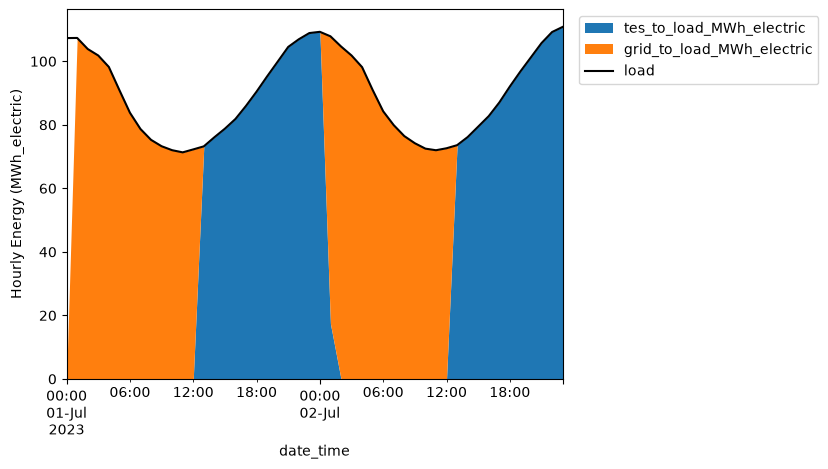

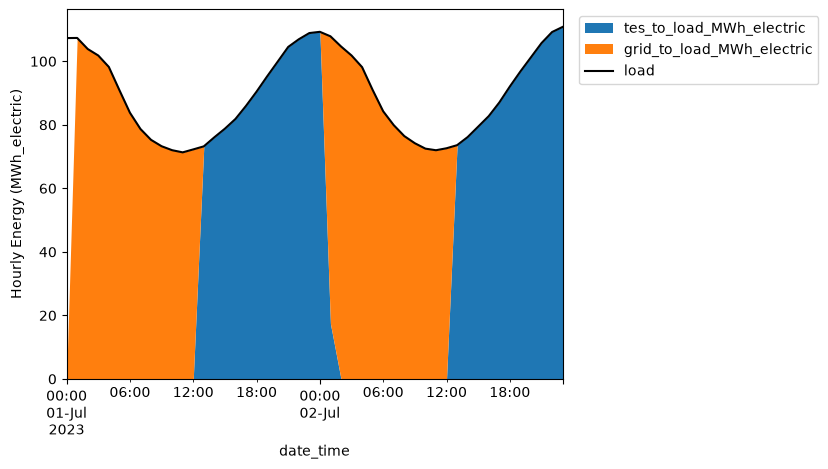

In [4]:
fig, ax = system.timeseries_plot_source(start_date=0, days=2)
fig

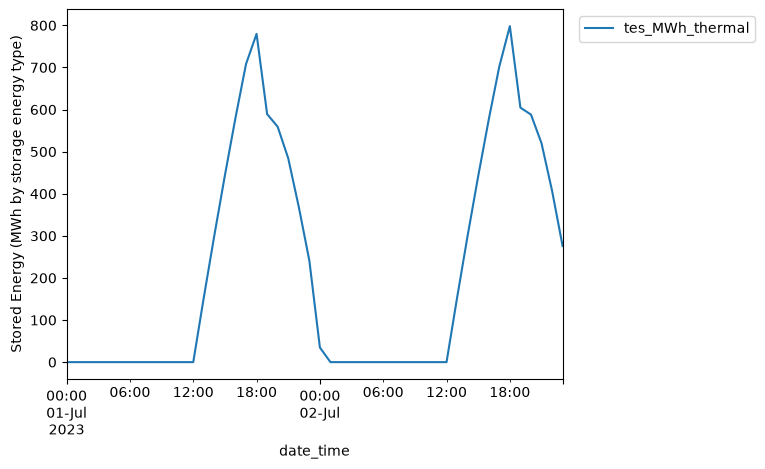

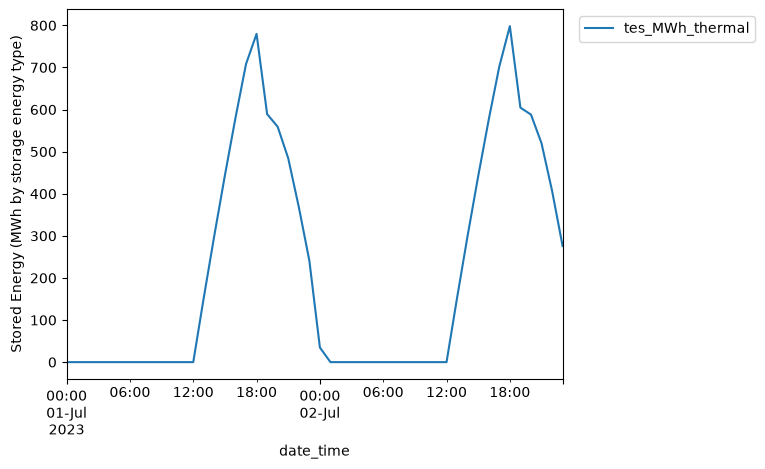

In [5]:
fig, ax = system.plot_storage_capacity(start_date=0, days=2)
fig

In [6]:
system.resilience_cases(critical_load_MW=20.0, target_hours=24, n_starts=20, seed=7)
system.resilience_summary

{'n_starts': 20,
 'pct_meets_actual': 35.0,
 'pct_meets_full': 100.0,
 'actual_reaches_end_pct': 35.0,
 'full_reaches_end_pct': 100.0,
 'tenth_pctile_actual_hrs': 0.0,
 'tenth_pctile_target_energy_actual_MWh_electric': 0.0,
 'tenth_pctile_target_energy_actual': 0.0,
 'tenth_pctile_pct_target_energy_actual': 58.612712198949545,
 'fiftieth_pctile_actual_hrs': 1.5,
 'fiftieth_pctile_target_energy_actual_MWh_electric': 30.0,
 'fiftieth_pctile_target_energy_actual': 30.0,
 'fiftieth_pctile_pct_target_energy_actual': 93.75,
 'ninetieth_pctile_actual_hrs': 24.0,
 'ninetieth_pctile_target_energy_actual_MWh_electric': 198.65898144504226,
 'ninetieth_pctile_target_energy_actual': 198.65898144504226,
 'ninetieth_pctile_pct_target_energy_actual': 100.0,
 'pct_meets_target_energy_actual': 35.0,
 'tenth_pctile_full_hrs': 24.0,
 'tenth_pctile_target_energy_full_MWh_electric': 0.0,
 'tenth_pctile_target_energy_full': 0.0,
 'tenth_pctile_pct_target_energy_full': 100.0,
 'fiftieth_pctile_full_hrs': 24.0